In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report,confusion_matrix

In [18]:
## Create datapoints
from sklearn.datasets import make_classification

In [11]:
X,y = make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=1,n_redundant=0)

In [12]:
X

array([[-1.02586815,  1.20427319],
       [-1.43411879,  2.82442021],
       [-0.97868695, -0.74391771],
       ...,
       [-1.78382296,  0.68376379],
       [-0.16837098, -1.41346666],
       [-1.76578149, -0.17341032]], shape=(1000, 2))

<Axes: xlabel='0', ylabel='1'>

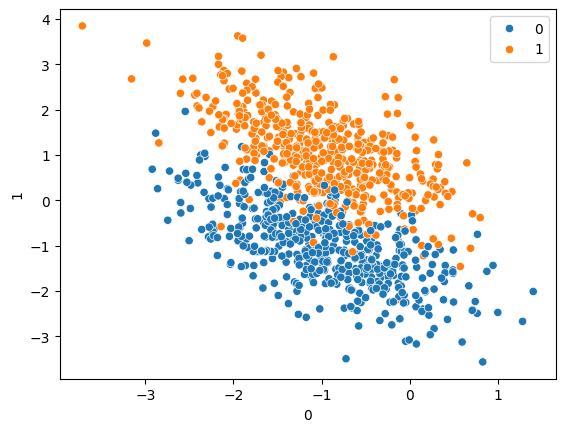

In [13]:
sns.scatterplot(x=pd.DataFrame(X)[0], y=pd.DataFrame(X)[1], hue=y)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [20]:
model = SVC(kernel='linear')
model.fit(X_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [21]:
perd = model.predict(X_test)

In [23]:
print(classification_report(y_test,perd))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       123
           1       0.93      0.95      0.94       127

    accuracy                           0.94       250
   macro avg       0.94      0.94      0.94       250
weighted avg       0.94      0.94      0.94       250



In [24]:
print(confusion_matrix(y_test,perd))

[[114   9]
 [  6 121]]


## RBF

In [31]:
X,y = make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=2,n_redundant=0)

In [32]:
X

array([[-2.16074864,  0.37612672],
       [-0.36503721, -0.03741288],
       [-0.83699228, -0.87815787],
       ...,
       [ 1.30782502, -0.35756892],
       [-0.33403488, -2.14477869],
       [-2.04149018,  2.5788403 ]], shape=(1000, 2))

<Axes: xlabel='0', ylabel='1'>

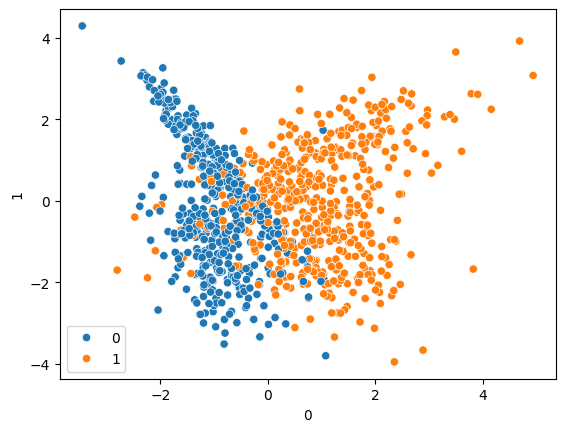

In [33]:
sns.scatterplot(x=pd.DataFrame(X)[0], y=pd.DataFrame(X)[1], hue=y)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [35]:
model = SVC(kernel='rbf')
model.fit(X_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [36]:
perd = model.predict(X_test)

In [37]:
print(classification_report(y_test,perd))

              precision    recall  f1-score   support

           0       0.89      0.90      0.89       131
           1       0.89      0.87      0.88       119

    accuracy                           0.89       250
   macro avg       0.89      0.89      0.89       250
weighted avg       0.89      0.89      0.89       250



In [38]:
print(confusion_matrix(y_test,perd))

[[118  13]
 [ 15 104]]


## Polynomial

In [40]:
model = SVC(kernel='poly')
model.fit(X_train,y_train)

,C,1.0
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [41]:
perd = model.predict(X_test)

In [42]:
print(classification_report(y_test,perd))

              precision    recall  f1-score   support

           0       0.93      0.81      0.87       131
           1       0.82      0.93      0.87       119

    accuracy                           0.87       250
   macro avg       0.87      0.87      0.87       250
weighted avg       0.88      0.87      0.87       250



In [43]:
print(confusion_matrix(y_test,perd))

[[106  25]
 [  8 111]]


## Sigmoid

In [44]:
model = SVC(kernel='sigmoid')
model.fit(X_train,y_train)

,C,1.0
,kernel,'sigmoid'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [45]:
perd = model.predict(X_test)

In [46]:
print(classification_report(y_test,perd))

              precision    recall  f1-score   support

           0       0.78      0.74      0.76       131
           1       0.73      0.76      0.75       119

    accuracy                           0.75       250
   macro avg       0.75      0.75      0.75       250
weighted avg       0.75      0.75      0.75       250



In [47]:
print(confusion_matrix(y_test,perd))

[[97 34]
 [28 91]]


## Hyperparameter Tuning

In [49]:
param_grid = {
    'C':[0.1,1,10,100,1000],
    'gamma':[1,0.1,0.01,0.001,0.0001],
    'kernel':['rbf']
}

In [51]:
model = GridSearchCV(SVC(),param_grid = param_grid,cv=5,refit=True,verbose=3)

In [52]:
model.fit(X_train,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.887 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.913 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.887 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.880 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.880 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.873 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.920 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.880 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.880 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.847 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.880 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1000


In [53]:
model.best_params_

{'C': 1000, 'gamma': 0.1, 'kernel': 'rbf'}

In [54]:
perd = model.predict(X_test)

In [55]:
print(classification_report(y_test,perd))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91       131
           1       0.91      0.88      0.90       119

    accuracy                           0.90       250
   macro avg       0.90      0.90      0.90       250
weighted avg       0.90      0.90      0.90       250



In [56]:
print(confusion_matrix(y_test,perd))

[[121  10]
 [ 14 105]]
